# Análise de Qualidade dos Dados da Tabela `extracao_mtech_data`

Este notebook tem como objetivo realizar uma análise inicial da qualidade dos dados carregados na tabela `extracao_mtech_data` do banco de dados SQLite. Serão verificadas inconsistências, valores ausentes, tipos de dados e a distribuição geral dos dados.

## Contexto dos Dados

Os dados nesta tabela representam informações semanais de lotes de aves, com registros para as idades de `[7, 14, 21, 28, 35, 42]` dias. Para a análise de qualidade, é importante considerar as seguintes metas e características do domínio:

*   **Idade Alvo de Abate:** 46 dias
*   **Peso Meta de Abate:** 3.250 kg
*   **Mortalidade ao Abate Meta:** 6%
*   **Linhagens de Aves:** COBB MALE, ROSS, HUBBARD

In [5]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações do banco de dados (ajuste conforme necessário)
DATABASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'database'))
DB_FILE = os.path.join(DATABASE_DIR, 'prediction_data.db')
TABLE_NAME = 'extracao_mtech_data'

# Conectar ao banco de dados
try:
    conn = sqlite3.connect(DB_FILE)
    print(f"Conectado ao banco de dados: {DB_FILE}")
except Exception as e:
    print(f"Erro ao conectar ao banco de dados: {e}")
    conn = None

# Carregar os dados para um DataFrame Pandas
if conn:
    try:
        df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
        print(f"Dados carregados com sucesso. Total de linhas: {len(df)}")
    except Exception as e:
        print(f"Erro ao carregar dados da tabela {TABLE_NAME}: {e}")
        df = pd.DataFrame()
    finally:
        conn.close()
        print("Conexão com o banco de dados fechada.")
else:
    df = pd.DataFrame()
    print("Não foi possível carregar os dados devido a um erro de conexão.")

Conectado ao banco de dados: c:\Users\user\Code\Git\prediction_weight_mortality\database\prediction_data.db
Dados carregados com sucesso. Total de linhas: 104601
Conexão com o banco de dados fechada.


## 1. Visão Geral dos Dados

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104601 entries, 0 to 104600
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   data_alojamento            104601 non-null  object 
 1   nome_fazenda               104595 non-null  object 
 2   data_hora_transao          104601 non-null  object 
 3   lote_composto              104599 non-null  object 
 4   data_evento                104601 non-null  object 
 5   idade                      104601 non-null  float64
 6   cab_alojadas               104601 non-null  float64
 7   estoque_aves               104601 non-null  float64
 8   mortalidade                104601 non-null  int64  
 9   _mortalidade               104601 non-null  float64
 10  descartados                104601 non-null  int64  
 11  _descartados               104601 non-null  float64
 12  _mortalidade__descartados  104601 non-null  float64
 13  data_criao                 10

In [7]:
df.head()

,data_alojamento,nome_fazenda,data_hora_transao,lote_composto,data_evento,idade,cab_alojadas,estoque_aves,mortalidade,_mortalidade,descartados,_descartados,_mortalidade__descartados,data_criao,peso,id_usurio_criao,extensionista,id_usurio,lote_prefixo
0,2023-10-30,SELVINO ORLANDO SPONCHIADO,2023-01-08,324-147,2023-01-08,-295.0,18500.0,-110.0,73,-66.36,37,0.20,-66.16,2023-11-11,0.201,anete.rorig,Cadastrar Veterinario,anete.rorig,324.0
1,2023-10-27,TEREZINHA RAIZI GOMES,2023-01-08,208-155,2023-01-08,-292.0,20200.0,-306.0,55,-17.97,98,0.49,-17.49,2023-11-06,0.199,ana.lunkes,Cadastrar Veterinario,ana.lunkes,208.0
2,2023-10-27,TEREZINHA RAIZI GOMES,2023-01-08,208-155,2023-01-08,-292.0,20200.0,-306.0,55,-17.97,98,0.49,-17.49,2023-11-23,0.199,ana.lunkes01,Cadastrar Veterinario,IIS APPPOOL\Def,208.0
3,2023-10-30,SELVINO ORLANDO SPONCHIADO,2023-01-15,324-147,2023-01-15,-288.0,18500.0,-175.0,30,-17.14,35,0.19,-16.95,2023-11-22,0.579,anete.rorig,Cadastrar Veterinario,anete.rorig,324.0
4,2023-10-27,TEREZINHA RAIZI GOMES,2023-01-15,208-155,2023-01-15,-285.0,20200.0,-478.0,37,-7.74,49,0.24,-7.50,2023-11-13,0.481,ana.lunkes,Cadastrar Veterinario,ana.lunkes,208.0


In [8]:
df.describe(include='all')

,data_alojamento,nome_fazenda,data_hora_transao,lote_composto,data_evento,idade,cab_alojadas,estoque_aves,mortalidade,_mortalidade,descartados,_descartados,_mortalidade__descartados,data_criao,peso,id_usurio_criao,extensionista,id_usurio,lote_prefixo
count,104601,104595,104601,104599,104601,104601.000000,104601.000000,104601.000000,104601.000000,104601.000000,104601.000000,104601.000000,104601.000000,104601,104601.000000,104600,104312,104600,104599.000000
unique,815,475,806,16132,818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,808,NaN,116,5,119,NaN
top,2023-02-18,CLEIFSON FERRARI GROSS,2025-01-18,962-55,2025-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-30,NaN,gabriela.zschor,Cadastrar Veterinario,gabriela.zschor,NaN
freq,243,1133,196,25,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,467,NaN,4531,84112,4537,NaN
mean,NaN,NaN,NaN,NaN,NaN,27.640348,24766.152102,20587.255877,180.478886,4.355852,83.466401,0.339310,4.696505,NaN,12.795135,NaN,NaN,NaN,733.823048
std,NaN,NaN,NaN,NaN,NaN,14.453607,6824.377267,10422.977045,705.801645,1399.945872,883.007423,4.990646,1399.953795,NaN,244.297005,NaN,NaN,NaN,347.789151
min,NaN,NaN,NaN,NaN,NaN,-329.000000,-10.000000,-59370.000000,0.000000,-14457.830000,0.000000,-330.000000,-14457.830000,NaN,0.000000,NaN,NaN,NaN,101.000000
25%,NaN,NaN,NaN,NaN,NaN,14.000000,18992.000000,16792.000000,55.000000,0.170000,23.000000,0.100000,0.340000,NaN,0.202000,NaN,NaN,NaN,440.000000
50%,NaN,NaN,NaN,NaN,NaN,28.000000,23995.000000,20647.000000,97.000000,0.330000,50.000000,0.210000,0.590000,NaN,0.988000,NaN,NaN,NaN,749.000000
75%,NaN,NaN,NaN,NaN,NaN,42.000000,31000.000000,29219.000000,187.000000,0.620000,96.000000,0.390000,1.020000,NaN,2.240000,NaN,NaN,NaN,1034.000000


## 2. Verificação de Valores Ausentes

In [9]:
df.isnull().sum()

data_alojamento                0
nome_fazenda                   6
data_hora_transao              0
lote_composto                  2
data_evento                    0
idade                          0
cab_alojadas                   0
estoque_aves                   0
mortalidade                    0
_mortalidade                   0
descartados                    0
_descartados                   0
_mortalidade__descartados      0
data_criao                     0
peso                           0
id_usurio_criao                1
extensionista                289
id_usurio                      1
lote_prefixo                   2
dtype: int64

## 3. Análise de Colunas Específicas

In [12]:
# Exemplo para colunas que eram problemáticas na conversão para inteiro
# Verifique valores únicos e suas contagens para identificar não-numéricos
problematic_cols = ['mortalidade', '_mortalidade', 'descartados', '_descartados', '_mortalidade__descartados', 'peso']

for col in problematic_cols:
    if col in df.columns:
        print(f"--- Análise da Coluna: {col} ---")
        print(df[col].value_counts(dropna=False).head(20)) # Mostra os 20 valores mais frequentes, incluindo NaN
        # Opcional: Filtrar valores não-numéricos se a coluna for do tipo 'object'
        # non_numeric_values = df[pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()][col].unique()
        # if len(non_numeric_values) > 0:
        #     print(f"Valores não-numéricos encontrados: {non_numeric_values}")
    else:
        print(f";Coluna {col} não encontrada no DataFrame.")

--- Análise da Coluna: mortalidade ---
mortalidade
40    856
50    853
60    851
55    822
65    804
52    794
57    794
49    789
53    780
56    772
70    770
42    769
54    769
45    764
46    763
63    755
59    747
48    746
43    745
41    738
Name: count, dtype: int64
--- Análise da Coluna: _mortalidade ---
_mortalidade
0.00    14453
0.22     1900
0.20     1888
0.24     1868
0.23     1824
0.19     1806
0.25     1798
0.21     1780
0.18     1759
0.26     1746
0.27     1707
0.17     1662
0.28     1601
0.16     1566
0.31     1530
0.29     1510
0.33     1484
0.30     1484
0.32     1461
0.15     1429
Name: count, dtype: int64
--- Análise da Coluna: descartados ---
descartados
0     10595
30     1192
20     1151
25     1084
35     1056
40     1054
50     1043
32     1043
28     1027
26     1018
33      996
27      995
38      992
34      988
31      988
23      983
37      982
45      965
24      963
29      961
Name: count, dtype: int64
--- Análise da Coluna: _descartados ---
_descar

### 3.1 Análise da Coluna `idade`

Verificar se os valores de `idade` estão dentro dos intervalos semanais esperados `[7, 14, 21, 28, 35, 42]` e se há registros com idade próxima ou igual à meta de abate (46 dias).


--- Análise da Coluna: idade ---
Valores únicos de idade:
idade
-329.0      1
-322.0      1
-295.0      1
-292.0      2
-288.0      1
           ..
 54.0      25
 55.0       3
 99.0       1
 171.0      1
 1029.0     1
Name: count, Length: 72, dtype: int64
Idades fora do padrão semanal esperado: [-295. -292. -288. -285. -281. -278. -274.    6.   13.   15.   16.   38.
   44.   45.   46.   47.   48.   49.   50. -329. -322. -267. -260.  -16.
    0.   20.   27.   34.   41.   43.   51.  -14.   10.   52.   12.  -38.
  -32.  -44.   53.   54.   55.  -50.  -17.   22.   23.   36.   18.   24.
   11.  171.  -19.  -15.    8.    9.   25.   29.   31. 1029.   37.    4.
   17.  -56.  -22.   30.  -21.   99.]

Registros com idade >= 46 dias (meta de abate):

idade
46.0      3257
47.0      3523
48.0      2421
49.0      1010
50.0       265
51.0       232
52.0        85
53.0        19
54.0        25
55.0         3
99.0         1
171.0        1
1029.0       1
Name: count, dtype: int64


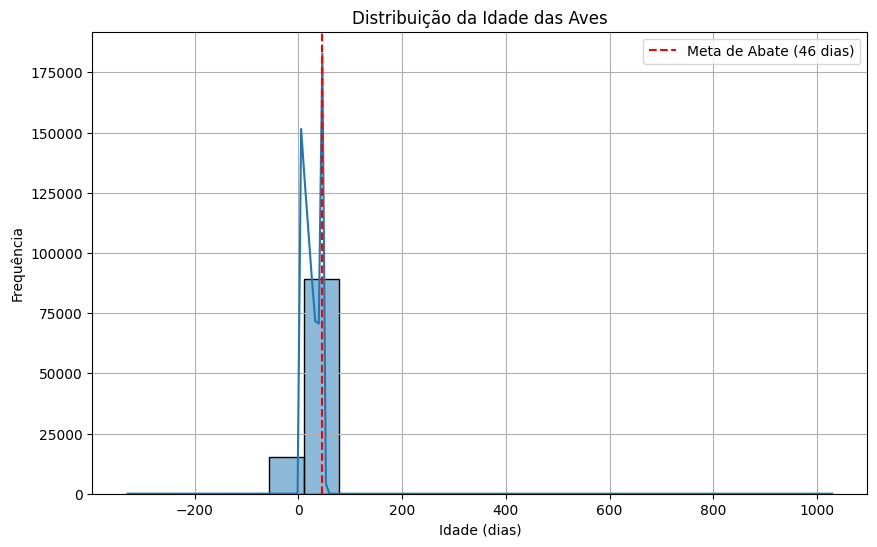

In [17]:
if 'idade' in df.columns:
    print("\n--- Análise da Coluna: idade ---")
    print("Valores únicos de idade:")
    print(df['idade'].value_counts().sort_index())

    # Verificar idades fora do padrão semanal
    expected_ages = [7, 14, 21, 28, 35, 42]
    unexpected_ages = df[~df['idade'].isin(expected_ages)]['idade'].unique()
    if len(unexpected_ages) > 0:
        print(f"Idades fora do padrão semanal esperado: {unexpected_ages}")

    # Verificar idades próximas à meta de abate
    slaughter_age_target = 46
    df_slaughter_age = df[df['idade'] >= slaughter_age_target]
    if not df_slaughter_age.empty:
        print(f"\nRegistros com idade >= {slaughter_age_target} dias (meta de abate):\n")
        print(df_slaughter_age['idade'].value_counts().sort_index())
    else:
        print(f"Nenhum registro com idade >= {slaughter_age_target} dias encontrado.")

    plt.figure(figsize=(10, 6))
    sns.histplot(df['idade'], bins=20, kde=True)
    plt.title('Distribuição da Idade das Aves')
    plt.xlabel('Idade (dias)')
    plt.ylabel('Frequência')
    plt.axvline(slaughter_age_target, color='r', linestyle='--', label=f'Meta de Abate ({slaughter_age_target} dias)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Coluna 'idade' não encontrada no DataFrame.")

### 3.2 Análise das Colunas `peso` e `mortalidade`

Avaliar a distribuição do `peso` e da `mortalidade` em relação às metas estabelecidas.

--- Análise da Coluna: peso ---
count    104601.000000
mean         12.795135
std         244.297005
min           0.000000
25%           0.202000
50%           0.988000
75%           2.240000
max       33333.000000
Name: peso, dtype: float64


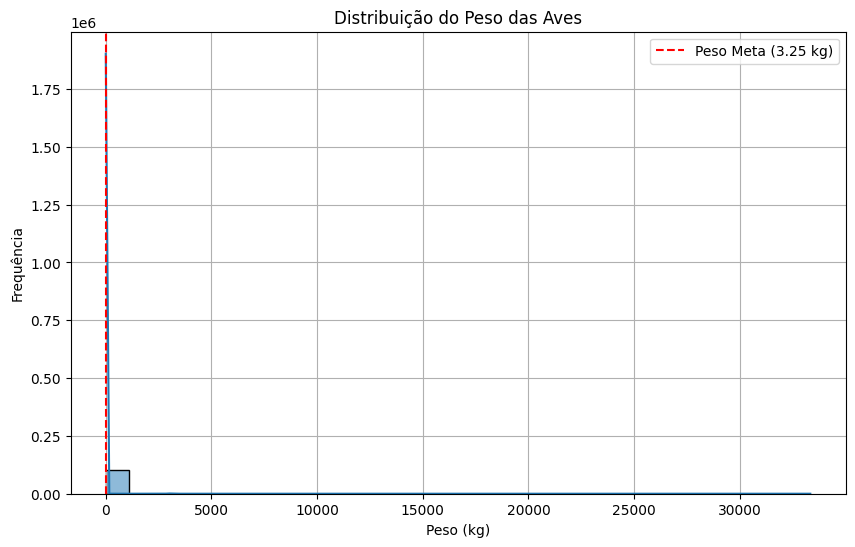

Registros com peso abaixo da meta (3.25 kg): 101805
Registros com peso igual ou acima da meta (3.25 kg): 2796
--- Análise da Coluna: _mortalidade ---
count    104601.000000
mean          4.355852
std        1399.945872
min      -14457.830000
25%           0.170000
50%           0.330000
75%           0.620000
max      452520.000000
Name: _mortalidade, dtype: float64


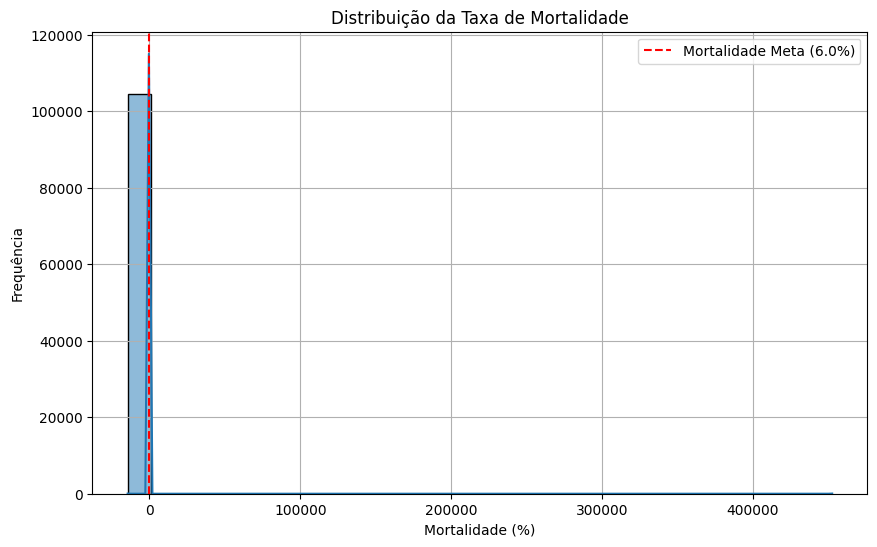

Registros com mortalidade acima da meta (6.0%): 630


In [21]:
if 'peso' in df.columns:
    print("--- Análise da Coluna: peso ---")
    print(df['peso'].describe())

    peso_meta = 3.250
    plt.figure(figsize=(10, 6))
    sns.histplot(df['peso'], bins=30, kde=True)
    plt.title('Distribuição do Peso das Aves')
    plt.xlabel('Peso (kg)')
    plt.ylabel('Frequência')
    plt.axvline(peso_meta, color='r', linestyle='--', label=f'Peso Meta ({peso_meta} kg)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Contagem de registros abaixo/acima da meta de peso
    below_target = df[df['peso'] < peso_meta].shape[0]
    above_target = df[df['peso'] >= peso_meta].shape[0]
    print(f"Registros com peso abaixo da meta ({peso_meta} kg): {below_target}")
    print(f"Registros com peso igual ou acima da meta ({peso_meta} kg): {above_target}")
else:
    print("Coluna 'peso' não encontrada no DataFrame.")

if '_mortalidade' in df.columns:
    print("--- Análise da Coluna: _mortalidade ---")
    print(df['_mortalidade'].describe())

    mortalidade_meta = 6.0 # em porcentagem
    plt.figure(figsize=(10, 6))
    sns.histplot(df['_mortalidade'], bins=30, kde=True)
    plt.title('Distribuição da Taxa de Mortalidade')
    plt.xlabel('Mortalidade (%)')
    plt.ylabel('Frequência')
    plt.axvline(mortalidade_meta, color='r', linestyle='--', label=f'Mortalidade Meta ({mortalidade_meta}%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Contagem de registros acima da meta de mortalidade
    above_target_mortality = df[df['_mortalidade'] > mortalidade_meta].shape[0]
    print(f"Registros com mortalidade acima da meta ({mortalidade_meta}%): {above_target_mortality}")
else:
    print("Coluna '_mortalidade' não encontrada no DataFrame.")

### 3.3 Análise das Colunas `lote_composto`, `nome_fazenda` e `lote_prefixo`

Explorar a unicidade e distribuição desses identificadores.

In [25]:
if 'lote_composto' in df.columns:
    print("\n--- Análise da Coluna: lote_composto ---")
    print(f"Número de lotes compostos únicos: {df['lote_composto'].nunique()}")
    print("Top 10 lotes compostos mais frequentes:")
    print(df['lote_composto'].value_counts().head(10))
else:
    print("Coluna 'lote_composto' não encontrada no DataFrame.")

if 'nome_fazenda' in df.columns:
    print("\n--- Análise da Coluna: nome_fazenda ---")
    print(f"Número de fazendas únicas: {df['nome_fazenda'].nunique()}")
    print("Top 10 fazendas mais frequentes:")
    print(df['nome_fazenda'].value_counts().head(10))
else:
    print("Coluna 'nome_fazenda' não encontrada no DataFrame.")

if 'lote_prefixo' in df.columns:
    print("\n--- Análise da Coluna: lote_prefixo ---")
    print(f"Número de prefixos de lote únicos: {df['lote_prefixo'].nunique()}")
    print("Distribuição dos prefixos de lote:")
    print(df['lote_prefixo'].value_counts().sort_index())
    # Verificar se há valores não numéricos ou nulos inesperados
    if df['lote_prefixo'].isnull().any():
        print(f"Valores nulos em 'lote_prefixo': {df['lote_prefixo'].isnull().sum()}")
else:
    print("Coluna 'lote_prefixo' não encontrada no DataFrame.")


--- Análise da Coluna: lote_composto ---
Número de lotes compostos únicos: 16132
Top 10 lotes compostos mais frequentes:
lote_composto
962-55     25
271-155    16
1220-16    16
520-111    14
1066-39    13
875-70     13
246-156    13
934-64     13
286-148    13
659-96     13
Name: count, dtype: int64

--- Análise da Coluna: nome_fazenda ---
Número de fazendas únicas: 475
Top 10 fazendas mais frequentes:
nome_fazenda
CLEIFSON FERRARI GROSS      1133
PAULO CEZAR HOFFMANN        1083
JOSE ANGELO GUSSI            909
DARLAN NIEDERMEYER SIMON     794
GILMAR MALACARNE             783
LEONARDO DE CASTRO SODRE     769
MERCIO FRANCISCO PALUDO      762
VALDIR ANOR DE ASSIS         753
ALFREDO LANG                 746
JEAN CARLOS BOTTINI          744
Name: count, dtype: int64

--- Análise da Coluna: lote_prefixo ---
Número de prefixos de lote únicos: 1134
Distribuição dos prefixos de lote:
lote_prefixo
101.0     95
102.0     92
103.0     98
104.0     98
105.0     98
          ..
1327.0     7
1328

### 3.4 Análise da Coluna `c16` (Linhagem)

Verificar a distribuição das linhagens e se correspondem às esperadas.

In [26]:
if 'c16' in df.columns:
    print("\n--- Análise da Coluna: c16 (Linhagem) ---")
    print("Distribuição das linhagens:")
    print(df['c16'].value_counts(dropna=False))

    expected_lineages = ['COBB MALE', 'ROSS', 'HUBBARD']
    unexpected_lineages = df[~df['c16'].isin(expected_lineages)]['c16'].unique()
    if len(unexpected_lineages) > 0:
        print(f"Linhagens inesperadas encontradas: {unexpected_lineages}")
else:
    print("Coluna 'c16' (Linhagem) não encontrada no DataFrame.")

Coluna 'c16' (Linhagem) não encontrada no DataFrame.


## 4. Conclusões e Próximos Passos

Com base nas análises realizadas, sumarize as principais observações sobre a qualidade dos dados e proponha os próximos passos para o tratamento e preparação dos dados para modelagem.

**Observações:**

*   **Valores Ausentes:** Identificar colunas com alta porcentagem de valores ausentes e discutir estratégias de tratamento (imputação, remoção).
*   **Consistência de Tipos:** Confirmar se os tipos de dados inferidos pelo Pandas (`df.info()`) estão corretos e se há necessidade de conversões adicionais.
*   **Outliers e Distribuições:** Analisar a presença de outliers em colunas numéricas (`peso`, `mortalidade`, `idade`) e a forma de suas distribuições.
*   **Conformidade com Metas:** Avaliar o quão próximos os dados estão das metas de abate (idade, peso, mortalidade) e identificar desvios significativos.
*   **Qualidade dos Identificadores:** Verificar a unicidade e consistência de `lote_composto`, `nome_fazenda` e `lote_prefixo`.
*   **Linhagens:** Confirmar a conformidade das linhagens com as esperadas e a presença de valores inconsistentes.

**Próximos Passos Sugeridos:**

*   **Tratamento de Valores Ausentes:** Definir e aplicar estratégias para lidar com NaNs.
*   **Limpeza de Dados:** Corrigir inconsistências identificadas (e.g., idades fora do padrão, linhagens inesperadas).
*   **Engenharia de Features:** Considerar a criação de novas features a partir das existentes (e.g., indicadores de desvio da meta, categorias de idade/peso).
*   **Análise Exploratória de Dados (EDA) Aprofundada:** Realizar análises bivariadas e multivariadas para entender as relações entre as variáveis.

In [ ]:
# Adicione aqui suas observações sobre a qualidade dos dados e os próximos passos para tratamento.